In [ ]:
# =======================
# 1. IMPORT LIBRARY
# =======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# =======================
# 2. DATA UNDERSTANDING
# =======================
df = pd.read_excel("hasil_rapi_mahasiswa.xlsx")

print("=== HEAD DATA ===")
print(df.head())

print("\n=== INFO DATA ===")
print(df.info())

print("\n=== DESKRIPSI ===")
print(df.describe())

=== HEAD DATA ===
                Timestamp                  Nama        NIM Jenis Kelamin  \
0 2026-04-08 19:28:14.979          Wa Rahmawati  F1G124019     Perempuan   
1 2026-04-08 19:29:13.016     Cahaya Ramadhani   F1G124059     Perempuan   
2 2026-04-08 19:35:52.182  Gusti Krisna Pranata  F1G123019     Laki-laki   
3 2026-04-08 19:37:10.771       Muhammad Safril  F1G123009     Laki-laki   
4 2026-04-08 19:37:28.266    Iqra Fauzan Akbar   F1G123020     Laki-laki   

   Angkatan Pendidikan terakhir orang tua  Nilai Logika matematika   \
0      2024                  Sarjana (S1)                        75   
1      2024                  Sarjana (S1)                        80   
2      2023                 SMA/Sederajat                        79   
3      2023               Tidak tamat SMA                        65   
4      2023                  Sarjana (S1)                        60   

   Nilai Bahasa Inggris  Nilai Bahasa Indonesia  Mengikuti bimbingan belajar   \
0                

In [ ]:
# =======================
# 3. DATA PREPROCESSING
# =======================

# Missing value
df = df.dropna()



In [ ]:
# Encoding kategorikal
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])



In [ ]:
print(df.columns)

Index(['Timestamp', 'Nama', 'NIM', 'Jenis Kelamin', 'Angkatan',
       'Pendidikan terakhir orang tua', 'Nilai Logika matematika ',
       'Nilai Bahasa Inggris', 'Nilai Bahasa Indonesia ',
       'Mengikuti bimbingan belajar ', 'Tingkat performa akademik '],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()
df = df.drop(["Nama", "NIM", "Timestamp"], axis=1)

In [ ]:
# Pisah fitur & target
X = df.drop("Tingkat performa akademik", axis=1)
y = df["Tingkat performa akademik"]

In [ ]:
# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

<Figure size 1400x1000 with 0 Axes>

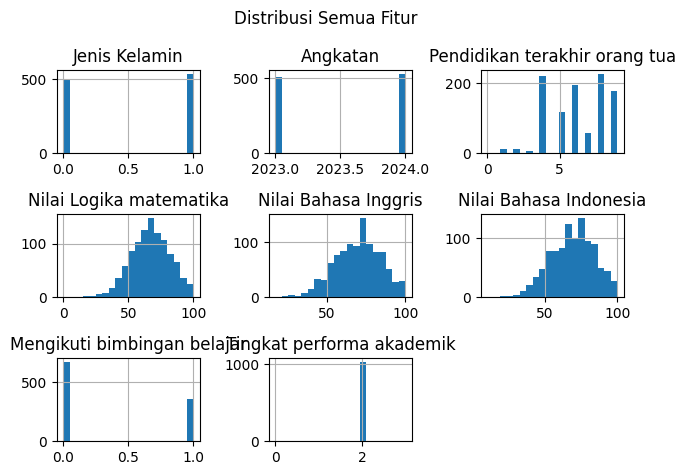

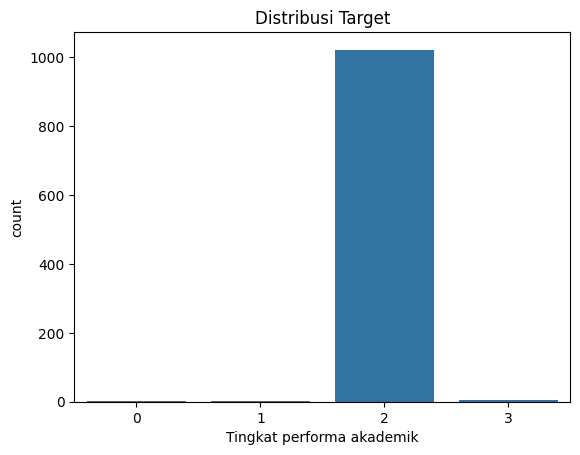

In [ ]:
# =======================
# 4. EDA
# =======================
plt.figure(figsize=(14,10))
df.hist(bins=20)
plt.suptitle("Distribusi Semua Fitur")
plt.tight_layout()
plt.show()

plt.figure()
sns.countplot(x=y)
plt.title("Distribusi Target")
plt.show()


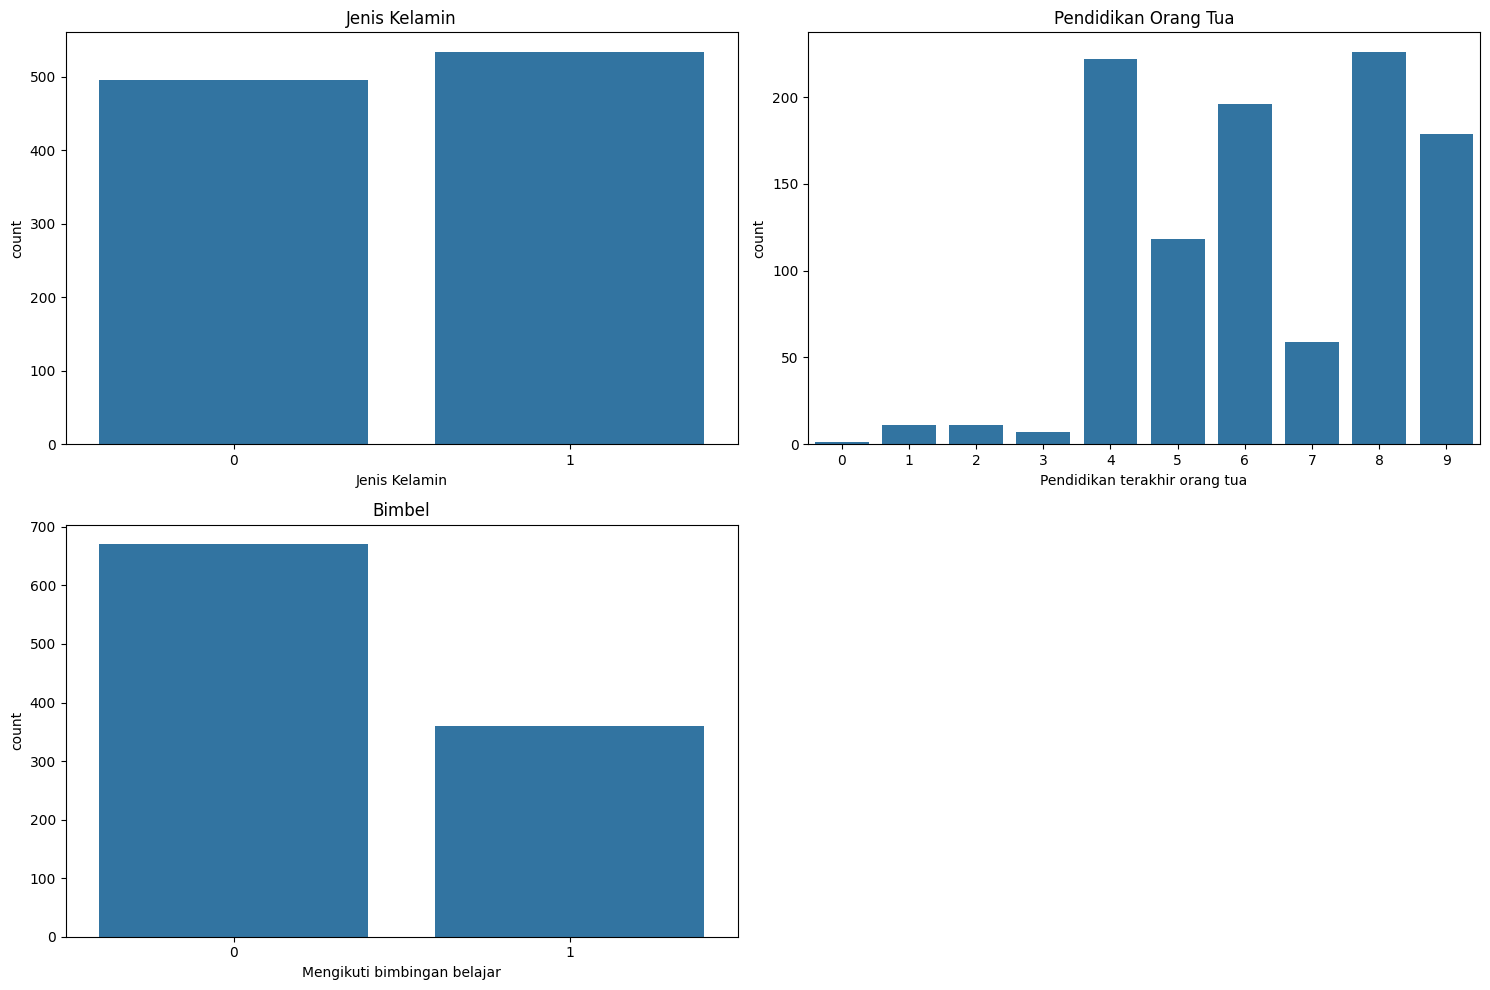

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(x=df['Jenis Kelamin'])
plt.title("Jenis Kelamin")

plt.subplot(2,2,2)
sns.countplot(x=df['Pendidikan terakhir orang tua'])
plt.title("Pendidikan Orang Tua")

plt.subplot(2,2,3)
sns.countplot(x=df['Mengikuti bimbingan belajar'])
plt.title("Bimbel")

plt.tight_layout()
plt.show()

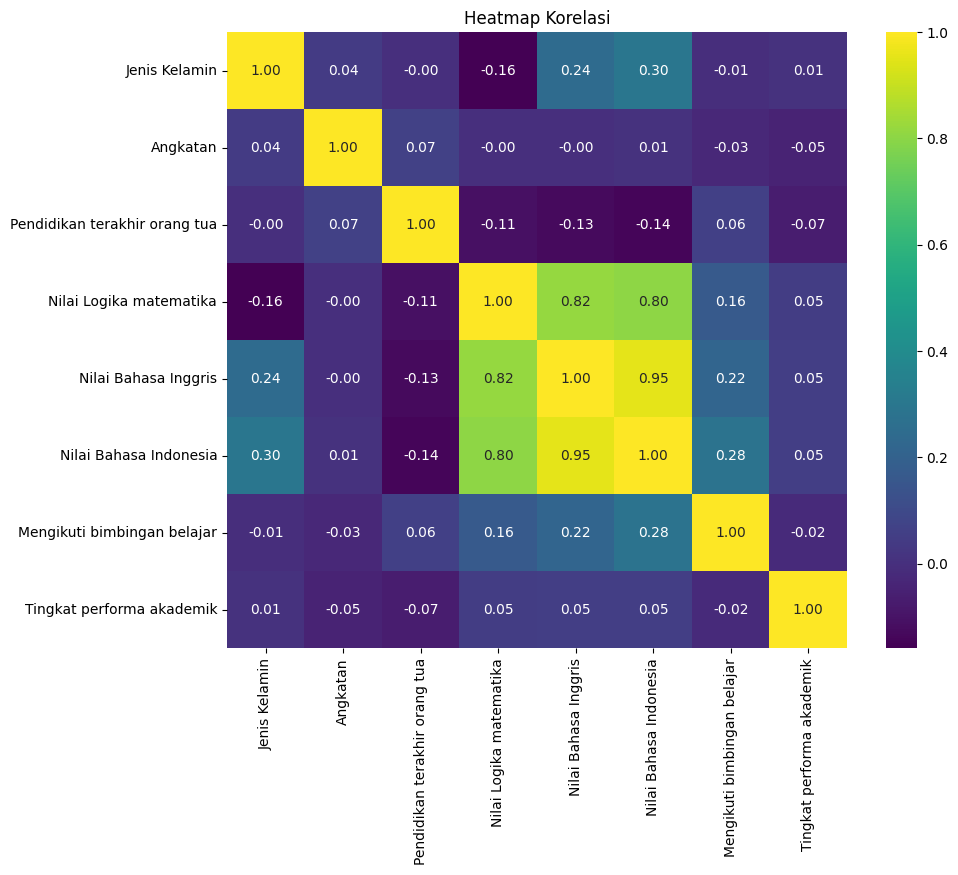

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Heatmap Korelasi")
plt.show()

In [ ]:
# =======================
# 5. SPLIT RATIO
# =======================
splits = [(0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]

results = []


In [ ]:
# =======================
# 6. MODEL + TUNING
# =======================
models = {
    "Decision Tree": (
        DecisionTreeClassifier(),
        {"max_depth": [3,5,10], "min_samples_split": [2,5,10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3,5,7], "weights": ["uniform","distance"]}
    ),
    "Random Forest": (
        RandomForestClassifier(),
        {"n_estimators": [50,100], "max_depth": [5,10]}
    )
}


=== SPLIT 70:30 ===

Decision Tree
Best Params: {'max_depth': 3, 'min_samples_split': 10}
Accuracy: 0.9838187702265372


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


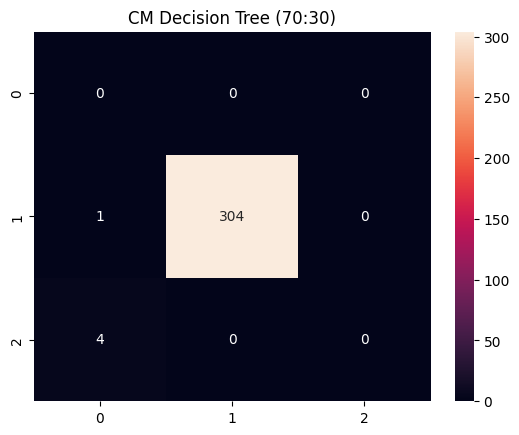

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



KNN
Best Params: {'n_neighbors': 3, 'weights': 'uniform'}
Accuracy: 0.9870550161812298


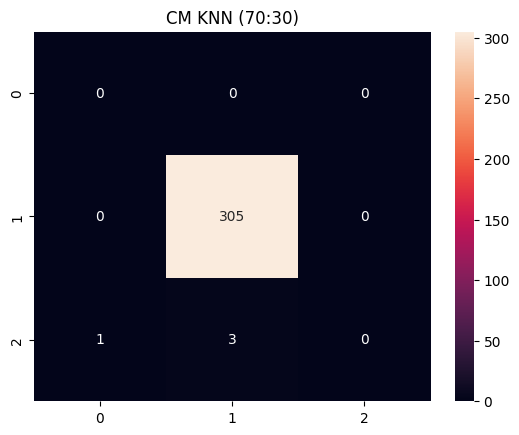

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Random Forest
Best Params: {'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.9870550161812298


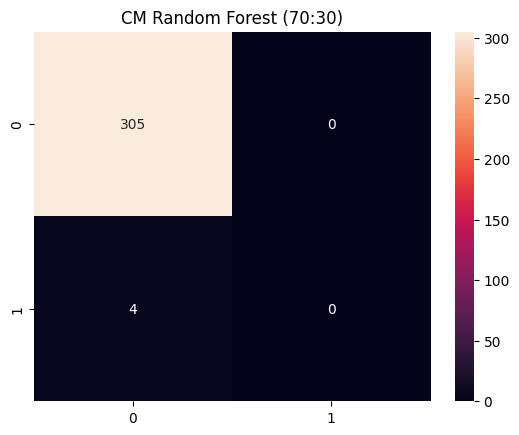


=== SPLIT 80:20 ===


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(



Decision Tree
Best Params: {'max_depth': 3, 'min_samples_split': 10}
Accuracy: 0.9951456310679612


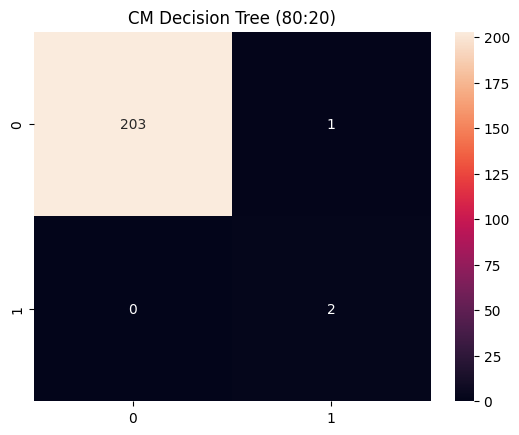

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



KNN
Best Params: {'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.9854368932038835


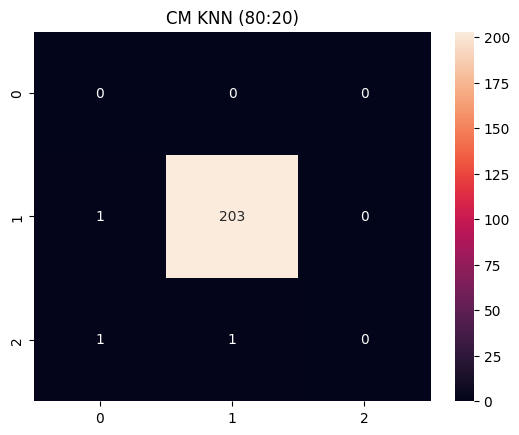

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Random Forest
Best Params: {'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.9902912621359223


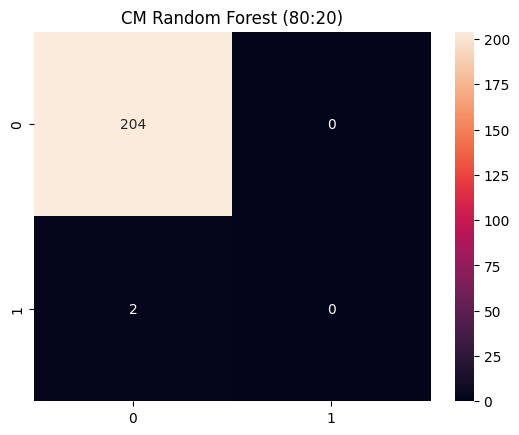


=== SPLIT 90:10 ===


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Decision Tree
Best Params: {'max_depth': 5, 'min_samples_split': 2}
Accuracy: 0.9902912621359223


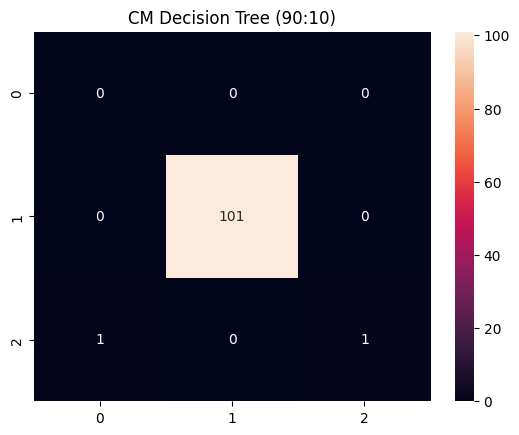

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



KNN
Best Params: {'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.9805825242718447


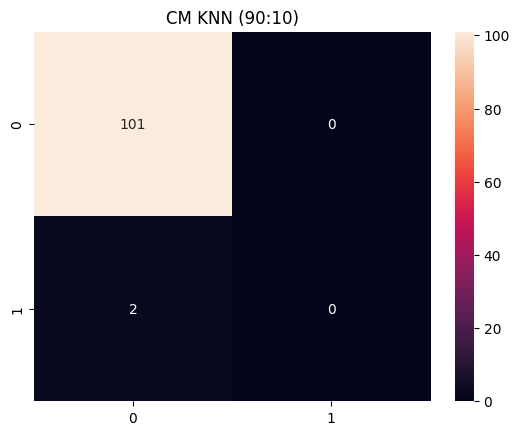

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(



Random Forest
Best Params: {'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.9805825242718447


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


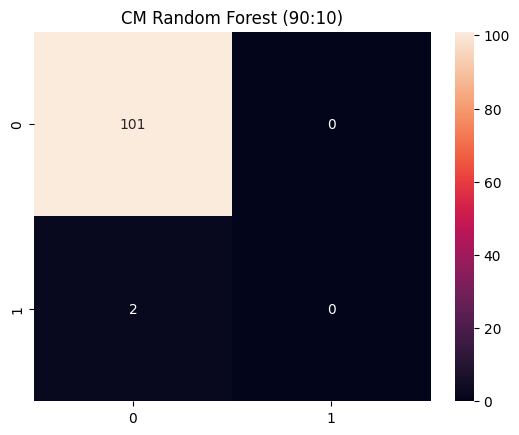

In [ ]:
# =======================
# 7. TRAINING & EVALUASI
# =======================
for train_size, test_size in splits:
    print(f"\n=== SPLIT {int(train_size*100)}:{int(test_size*100)} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for name, (model, params) in models.items():
        grid = GridSearchCV(model, params, cv=3)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print(f"\n{name}")
        print("Best Params:", grid.best_params_)
        print("Accuracy:", acc)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f"CM {name} ({int(train_size*100)}:{int(test_size*100)})")
        plt.show()

        results.append({
            "Model": name,
            "Split": f"{int(train_size*100)}:{int(test_size*100)}",
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })


=== HASIL AKHIR ===
           Model  Split  Accuracy  Precision    Recall        F1
0  Decision Tree  70:30  0.983819   0.987055  0.983819  0.985434
1            KNN  70:30  0.987055   0.977441  0.987055  0.982224
2  Random Forest  70:30  0.987055   0.974278  0.987055  0.980625
3  Decision Tree  80:20  0.995146   0.996764  0.995146  0.995625
4            KNN  80:20  0.985437   0.985437  0.985437  0.985437
5  Random Forest  80:20  0.990291   0.980677  0.990291  0.985461
6  Decision Tree  90:10  0.990291   1.000000  0.990291  0.993528
7            KNN  90:10  0.980583   0.961542  0.980583  0.970969
8  Random Forest  90:10  0.980583   0.961542  0.980583  0.970969


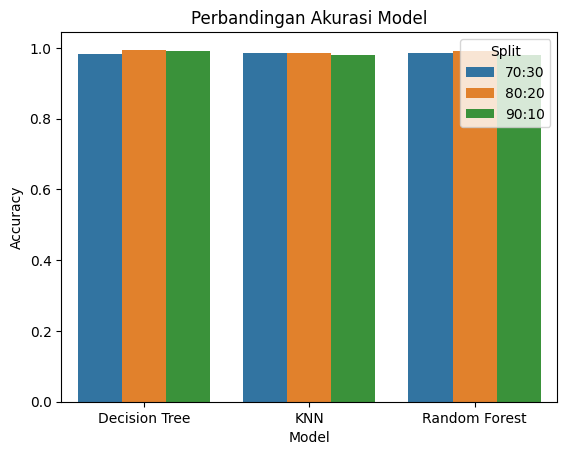

In [ ]:
# =======================
# 8. MODEL COMPARISON
# =======================
df_results = pd.DataFrame(results)
print("\n=== HASIL AKHIR ===")
print(df_results)

# Grafik perbandingan
plt.figure()
sns.barplot(data=df_results, x="Model", y="Accuracy", hue="Split")
plt.title("Perbandingan Akurasi Model")
plt.show()